<a href="https://colab.research.google.com/github/sionide/CMPE-131-HW3/blob/main/LinearRegressionComplete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Credits: Part of this notebook was generated by Google Colab's AI agent

In [41]:
import numpy as np
import matplotlib.pyplot as plt

In [42]:
import random

## Generates N random points for logistic regression on a line w
def generate_lr(N=20,w0=0,w1=1):
    n = 0
    X1 = []
    Y = []
    while(n < N):
        x1 = random.uniform(-10,10)
        x2 = random.uniform(-1,1)
        y = w0 + w1*x1 + x2
        X1.append(x1)
        Y.append(y)
        n += 1
    data = [np.array([1,X1[i],Y[i]]) for i in range(N)]
    return data

In [43]:
f_w0, f_w1 = 1, 1
N = 50
data = generate_lr(N, f_w0, f_w1)

In [44]:
def abline(slope, intercept, color='b', label=None):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--', label=label, c=color)

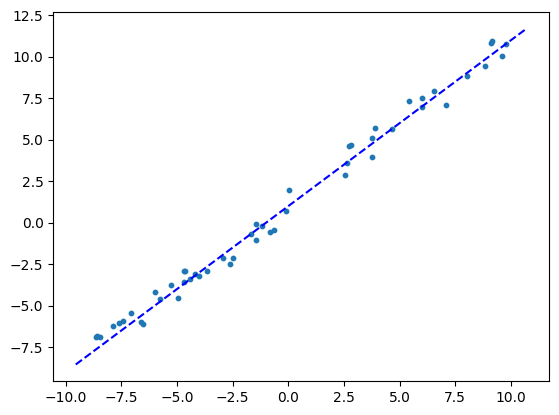

In [45]:
X1 = [i[1] for i in data]
Y  = [i[2] for i in data]
markers = [] #'o' or '+'
colors = [] # 'b' or 'r'
cnt = 0
plt.scatter(X1,Y, s = 10)

abline(f_w1,f_w0)
plt.show()

In [46]:
X = [[i[0], i[1]] for i in data]
Y  = [i[2] for i in data]

In [47]:
X = np.array(X)
Y = np.array(Y)
XtX = np.matmul(X.T, X)

In [48]:
XtX_inv = np.linalg.inv(XtX)
XtX_inv.shape
XtX_inv

array([[0.02014743, 0.00030462],
       [0.00030462, 0.00062943]])

In [49]:
## XtX = np.matmul(X, np.transpose(X))
## XtX.shape

In [50]:
X_pi = np.matmul(XtX_inv, np.transpose(X))
X_pi

array([[ 2.29158129e-02,  1.83292195e-02,  1.93884053e-02,
         2.12949528e-02,  1.85355297e-02,  1.75763118e-02,
         2.15654259e-02,  2.01161248e-02,  1.78832792e-02,
         2.29349255e-02,  1.97044047e-02,  2.19771716e-02,
         1.97040341e-02,  2.09831858e-02,  2.31283197e-02,
         1.77434438e-02,  1.78289285e-02,  1.86305305e-02,
         1.96308019e-02,  1.87203738e-02,  1.83948387e-02,
         2.12906809e-02,  2.19700837e-02,  2.09520038e-02,
         2.21466009e-02,  1.87391133e-02,  1.98925221e-02,
         1.87217640e-02,  1.81269682e-02,  1.81596405e-02,
         2.13293111e-02,  1.88065365e-02,  1.79881181e-02,
         1.93550068e-02,  1.88664465e-02,  1.97809396e-02,
         1.75185836e-02,  2.09991297e-02,  2.23011170e-02,
         1.99555211e-02,  2.30723478e-02,  1.89281317e-02,
         2.09281694e-02,  1.75285972e-02,  2.17947668e-02,
         2.01548301e-02,  2.28338291e-02,  1.92487291e-02,
         1.90391855e-02,  2.25853054e-02],
       [ 6.02

In [51]:
w = np.matmul(X_pi, Y)
w

array([1.10288074, 0.98756044])

Plot the final hypothesis with the target and the data points

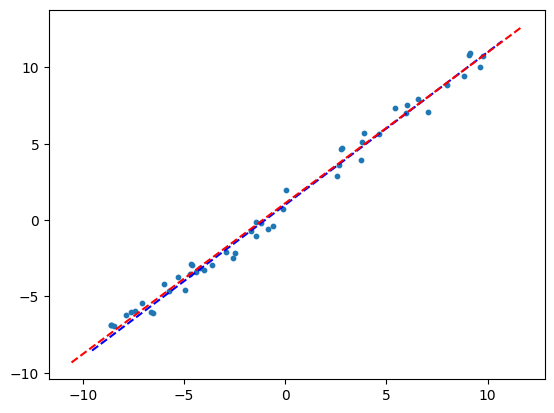

In [52]:
X1 = [i[1] for i in data]
Y  = [i[2] for i in data]
plt.scatter(X1,Y, s = 10)

abline(f_w1,f_w0)
abline(w[1],w[0], color='r')
plt.show()

In [53]:
Y_pred = np.matmul(X, w)
np.sum(np.square(Y_pred-Y))

np.float64(15.978193788631181)

In [54]:
w_other = [3, 2]
Y_other = np.matmul(X, w_other)
np.sum(np.square(Y_other-Y))

np.float64(1743.4873465244723)

What about the test data set?

In [55]:
#50 test samples
testdata = generate_lr(50, f_w0, f_w1)
X_test = [[i[0], i[1]] for i in testdata]
Y_test  = [i[2] for i in testdata]
Y_pred_test = np.matmul(X_test, w)
np.sum(np.square(Y_pred_test-Y_test))

np.float64(12.082717482761945)

In [56]:
Y_pred_test_target = np.matmul(X_test, [1, 1])
np.sum(np.square(Y_pred_test_target-Y_test))

np.float64(12.12871149972473)

Library implementation of linear regression




In [57]:
from sklearn.linear_model import LinearRegression

In [58]:
model = LinearRegression()
model.fit(np.array(X)[:, 1].reshape(-1, 1), Y)

LinearRegression()

### Learned coefficients from `sklearn`

In [59]:
print(f"Intercept (w0): {model.intercept_}")
print(f"Coefficient (w1): {model.coef_[0]}")

Intercept (w0): 1.1028807367450328
Coefficient (w1): 0.9875604412344124


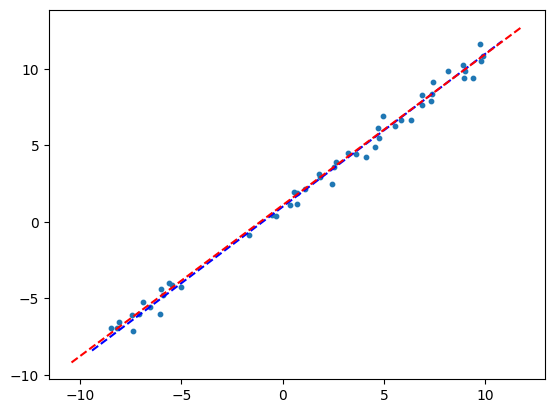

In [60]:
X_test = np.array(X_test)
Y_test = np.array(Y_test)
plt.scatter(X_test[:, 1], Y_test, s=10)
abline(f_w1, f_w0)
abline(w[1], w[0], color="r")
plt.show()

### Sum of squared errors on training data (`sklearn`)

In [61]:
Y_pred_sklearn = model.predict(np.array(X)[:, 1].reshape(-1, 1))
np.sum(np.square(Y_pred_sklearn - Y))

np.float64(15.978193788631177)

### Sum of squared errors on test data (`sklearn`)

In [62]:
Y_pred_test_sklearn = model.predict(np.array(X_test)[:, 1].reshape(-1, 1))
np.sum(np.square(Y_pred_test_sklearn - Y_test))

np.float64(12.082717482761945)

### Comparison of Analytical and `sklearn` Results

In [63]:
print(f"Analytical Solution Coefficients: w0 = {w[0]:.4f}, w1 = {w[1]:.4f}")
print(f"Sklearn Coefficients:           w0 = {model.intercept_:.4f}, w1 = {model.coef_[0]:.4f}")

print(f"\nAnalytical Solution SSE (Training): {np.sum(np.square(np.matmul(X, w) - Y)):.4f}")
print(f"Sklearn SSE (Training):             {np.sum(np.square(model.predict(np.array(X)[:, 1].reshape(-1, 1)) - Y)):.4f}")

print(f"\nAnalytical Solution SSE (Test): {np.sum(np.square(np.matmul(X_test, w) - Y_test)):.4f}")
print(f"Sklearn SSE (Test):             {np.sum(np.square(model.predict(np.array(X_test)[:, 1].reshape(-1, 1)) - Y_test)):.4f}")

Analytical Solution Coefficients: w0 = 1.1029, w1 = 0.9876
Sklearn Coefficients:           w0 = 1.1029, w1 = 0.9876

Analytical Solution SSE (Training): 15.9782
Sklearn SSE (Training):             15.9782

Analytical Solution SSE (Test): 12.0827
Sklearn SSE (Test):             12.0827


### Plotting Analytical vs. `sklearn` Regression Lines

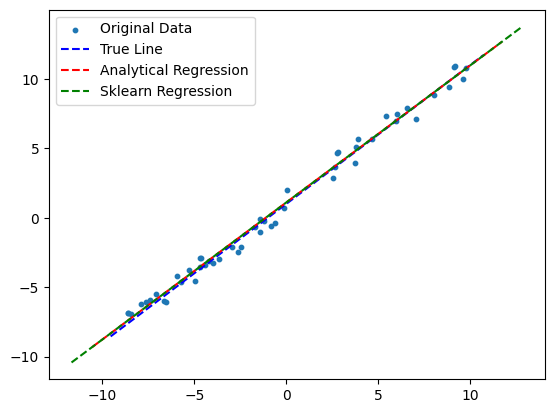

In [64]:
plt.scatter(X1, Y, s=10, label='Original Data')
abline(f_w1, f_w0, color='b', label='True Line')
abline(w[1], w[0], color='r', label='Analytical Regression')
abline(model.coef_[0], model.intercept_, color='g', label='Sklearn Regression')
plt.legend()
plt.show()

Comment on the following question:

Would you be able to use the metrics we studied in logistic regression for linear regression as well? Why?

D. No because logistic regression is good at classification. Linear regression is better at predicting using numberical inputs.

C. The results are almost the same. After changing the data the line becomes less accurate and the error is larger =.